In [1]:
# Imports
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from scipy.interpolate import PchipInterpolator
from scipy.interpolate import make_interp_spline
from scipy.optimize import curve_fit

In [2]:
current_directory = Path.cwd().parent
discharge_directory = Path.joinpath(current_directory, "Data Start Point")

compiled_file_name = Path.joinpath(discharge_directory, "final_cleaned_compiled.csv")
points_of_interest_file_name = Path.joinpath(discharge_directory, "points_of_interest.json")
RC_values_file_name = Path.joinpath(discharge_directory, "RC_values.csv")
ocv_soc_dict_file_name = Path.joinpath(discharge_directory, "ocv_soc_dict.csv")

output_file_name = Path.joinpath(discharge_directory, "final_cleaned_compiled (with SoC).csv")

In [3]:
points_of_interest = json.load(open(points_of_interest_file_name, 'r'))

In [4]:
compiled_df = pd.read_csv(compiled_file_name)

In [5]:
average_current = ((compiled_df['Calibrated Current 1'] + compiled_df['Calibrated Current 2']) / 2 + 
                   ((compiled_df['Calibrated Current 1'] + compiled_df['Calibrated Current 2']) / 2).shift(1)) / 2
average_current[average_current < 0] = 0
average_current = average_current.fillna(0)

delta_time = compiled_df['Translated Time'].diff() / 1000  # Convert ms to seconds
delta_time = delta_time.fillna(0)

compiled_df['Charge Change'] = average_current * delta_time

sensor_draw_estimate = 0.081

total_Ah = (compiled_df['Charge Change'].sum() / 3600) - sensor_draw_estimate

print(f"Total Ah: {total_Ah:.4f} Ah")

Total Ah: 73.3691 Ah


In [6]:
compiled_df['SoC'] = 100.0
# SoC from discharge curve
total_charge = total_Ah * 3600  # Convert Ah to Coulombs
accumulated_charge = 0.0
for index, row in compiled_df.iterrows():
    if index % 10000 == 0:
        print(f"Calculating SoC for row {index}/{len(compiled_df)}", end='\r')
    
    compiled_df.at[index, 'SoC'] = total_charge - accumulated_charge
    accumulated_charge += row['Charge Change']

compiled_df["SoC"] = compiled_df["SoC"] / total_charge * 100

In [7]:
compiled_df.head(10)

,Translated Time,Translated Time (minutes),ADS Reading 1 (Smoothed and Offset),Calibrated Current 1,ADS Reading 2 (Smoothed and Offset),Calibrated Current 2,ADS Reading 3 (Smoothed),Calibrated Voltage,Charge Change,SoC
0,1000,0.016667,2.863429,0.008564,4.816303,0.014406,25542.0,58.202529,0.000000,100.000000
1,1032,0.017200,-1.136571,-0.003399,4.816303,0.014406,25541.5,58.202529,0.000272,100.000000
2,1064,0.017733,1.863429,0.005573,4.816303,0.014406,25541.0,58.197972,0.000248,100.000000
3,1095,0.018250,1.863429,0.005573,4.816303,0.014406,25541.0,58.200251,0.000310,100.000000
4,1126,0.018767,-3.136571,-0.009381,4.816303,0.014406,25541.0,58.200251,0.000194,100.000000
5,1157,0.019283,-4.136571,-0.012372,4.816303,0.014406,25541.0,58.200251,0.000055,100.000000
6,1189,0.019817,-3.136571,-0.009381,4.816303,0.014406,25541.0,58.200251,0.000056,100.000000
7,1220,0.020333,-3.136571,-0.009381,4.816303,0.014406,25541.0,58.200251,0.000078,100.000000
8,1251,0.020850,2.863429,0.008564,4.816303,0.014406,25541.0,58.200251,0.000217,100.000000
9,1283,0.021383,3.863429,0.011555,4.816303,0.014406,25541.0,58.200251,0.000391,99.999999


In [10]:
before_close = points_of_interest['before_close']
before_open = points_of_interest['before_open']
before_close['SoC'] = []
before_open['SoC'] = []
for index in before_close['index']:
    before_close['SoC'].append(compiled_df.at[index, 'SoC'])

for index in before_open['index']:
    before_open['SoC'].append(compiled_df.at[index, 'SoC'])
    
print(f"Before Close: {json.dumps(before_close)}")
print(f"Before Open: {json.dumps(before_open)}")
print(len(before_close['SoC']), len(before_close['voltage']))
print(len(before_open['SoC']), len(before_open['voltage']))

Before Close: {"index": [237, 32509, 95076, 157482, 206298, 246533, 279795, 318876, 377440, 424264, 468226, 513287, 554737, 613499], "time": [0.2184333333333333, 27.8193975, 75.08670250000002, 120.46748749999999, 163.25703083333335, 194.5483975, 221.33049333333332, 253.54922499999998, 298.1285075, 337.3006066666667, 382.17072333333334, 426.609135, 466.993075, 510.58498999999995], "voltage": [58.20104818239796, 57.050760937500016, 56.33354043367346, 55.4055402742347, 54.103719547193876, 53.1238789859694, 52.38284607780612, 51.80132209821429, 51.349797895408166, 50.840964413265326, 50.253971556122465, 49.443096524234704, 49.10368431122449, 46.61363600127551], "SoC": [99.99994070007475, 92.24186417492278, 84.89168657041738, 76.41912710991043, 68.80855211746446, 61.37238784575071, 54.93983212348699, 47.981014413494414, 40.127069767158865, 32.719945369841376, 25.115365245330683, 18.135361494856074, 11.122567943198005, 4.159656579343209]}
Before Open: {"index": [13297, 46691, 112353, 168972,

In [11]:
trimmed_df = compiled_df[:618898 ]

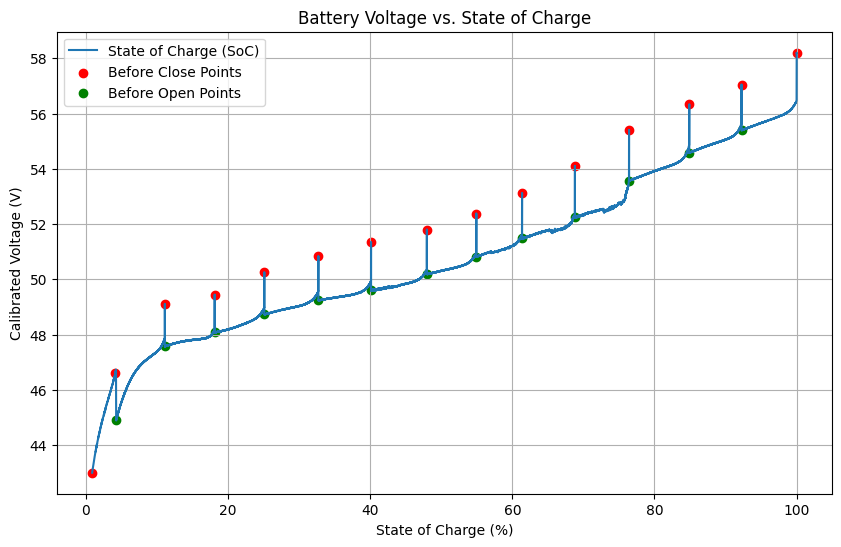

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(trimmed_df['SoC'], trimmed_df['Calibrated Voltage'], label='State of Charge (SoC)')
plt.scatter(before_close['SoC'], before_close['voltage'], color='red', label='Before Close Points')
plt.scatter(before_open['SoC'], before_open['voltage'], color='green', label='Before Open Points')
plt.xlabel('State of Charge (%)')
plt.ylabel('Calibrated Voltage (V)')
plt.title('Battery Voltage vs. State of Charge')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
# As the final OCV at SoC = 0
last_point = trimmed_df.iloc[-1]

if before_close['index'][-1] != len(trimmed_df) - 1:
    before_close['SoC'].append(last_point['SoC'])
    before_close['voltage'].append(last_point['Calibrated Voltage'])
    before_close['index'].append(len(trimmed_df) - 1)
    
    print(f"Added last point to before_close: SoC={last_point['SoC']}, Voltage={last_point['Calibrated Voltage']}, Index={len(trimmed_df) - 1}")

Added last point to before_close: SoC=0.8935298011779255, Voltage=42.99677104591837, Index=618897


In [25]:
ocv_model = lambda soc, a, b, c, d, e: a + b * soc + c * soc**2 + d * np.log(soc) + e * np.log(100 - soc)
parameters, covariance = curve_fit(ocv_model, before_close['SoC'], before_close['voltage'], p0=[0.0, 0.01, -0.0001, 0.1, 0.1])
a, b, c, d, e = parameters
print(f"Fitted OCV model parameters: a={a:.5f}, b={b:.5f}, c={c:.5f}, d={d:.5f}, e={e:.5f}")

Fitted OCV model parameters: a=43.14676, b=-0.09145, c=0.00127, d=2.60306, e=0.04823


In [26]:
def filter_df(soc, ocv, index_to_rm=[]):
    new_soc = []
    new_ocv = []
    for i in range(len(soc)):
        if i not in index_to_rm:
            new_soc.append(soc[i])
            new_ocv.append(ocv[i])
    return new_soc, new_ocv

C:\Users\Kor\AppData\Local\Temp\ipykernel_34236\3450962758.py:1: RuntimeWarning: divide by zero encountered in log
  ocv_model = lambda soc, a, b, c, d, e: a + b * soc + c * soc**2 + d * np.log(soc) + e * np.log(100 - soc)


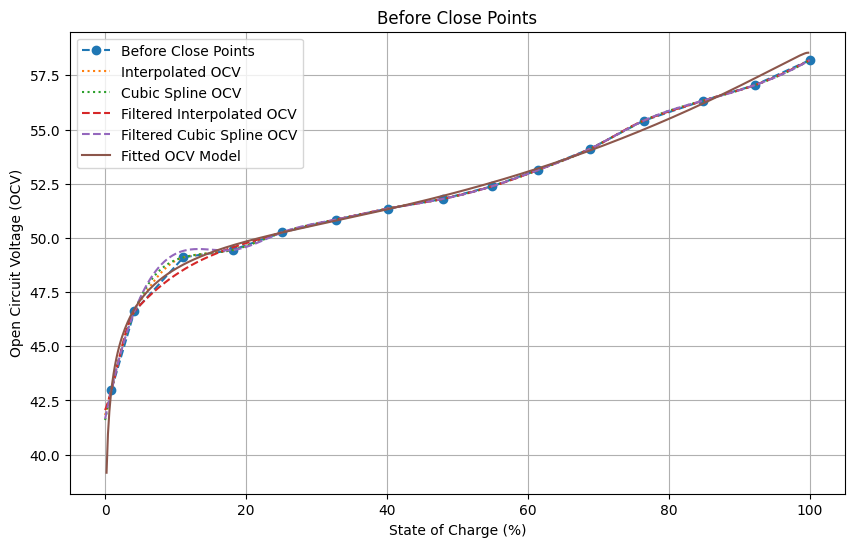

In [27]:
soc = np.flip(np.array(before_close['SoC'].copy()))
ocv = np.flip(np.array(before_close['voltage'].copy()))
soc_smooth = np.linspace(0, 100, 500)

piecewise_cubic_interp = PchipInterpolator(soc, ocv)
piecewise_cubic_spline_ocv_smooth = piecewise_cubic_interp(soc_smooth)

filtered_piecewise_cubic_interp = PchipInterpolator(*filter_df(soc, ocv, index_to_rm=[2, 3]))
filtered_piecewise_cubic_spline_ocv_smooth = filtered_piecewise_cubic_interp(soc_smooth)

cubic_spline_interp = make_interp_spline(soc, ocv)
cubic_spline_ocv_smooth = cubic_spline_interp(soc_smooth)

filtered_cubic_spline_interp = make_interp_spline(*filter_df(soc, ocv, index_to_rm=[2]))
filtered_cubic_spline_ocv_smooth = filtered_cubic_spline_interp(soc_smooth)

plt.figure(figsize=(10, 6))
plt.plot(before_close['SoC'], before_close['voltage'], label='Before Close Points', linestyle='--', marker='o')
plt.plot(soc_smooth, piecewise_cubic_spline_ocv_smooth, label='Interpolated OCV', linestyle=':')
plt.plot(soc_smooth, cubic_spline_ocv_smooth, label='Cubic Spline OCV', linestyle=':')

plt.plot(soc_smooth, filtered_piecewise_cubic_spline_ocv_smooth, label='Filtered Interpolated OCV', linestyle='--')
plt.plot(soc_smooth, filtered_cubic_spline_ocv_smooth, label='Filtered Cubic Spline OCV', linestyle='--')

plt.plot(soc_smooth, ocv_model(soc_smooth, *parameters), label='Fitted OCV Model', linestyle='-')

plt.xlabel('State of Charge (%)')
plt.ylabel('Open Circuit Voltage (OCV)')
plt.title('Before Close Points')
plt.legend()
plt.grid(True)
plt.show()

In [28]:
# Piecewise Function

print("Function: f(x) = c0*(x-x_i)^3 + c1*(x-x_i)^2 + c2*(x-x_i) + c3 for x in [x_i, x_{i+1}]")
knots = piecewise_cubic_interp.x
coef = piecewise_cubic_interp.c
intervals = len(coef[0])
print(f"Total number of intervals: {intervals}")
for i in range(intervals):
    print(f"Interval {i}:\tx in [{knots[i]}, {knots[i+1]}]")
    print(f"\t\tCoefficients: c0={coef[0][i]}, c1={coef[1][i]}, c2={coef[2][i]}, c3={coef[3][i]}")

Function: f(x) = c0*(x-x_i)^3 + c1*(x-x_i)^2 + c2*(x-x_i) + c3 for x in [x_i, x_{i+1}]
Total number of intervals: 14
Interval 0:	x in [0.8935298011779255, 4.159656579343209]
		Coefficients: c0=-0.027356077694069343, c1=0.016050166775357227, c2=1.3467879585440017, c3=42.99677104591837
Interval 1:	x in [4.159656579343209, 11.122567943198005]
		Coefficients: c0=-0.0011083150868672006, c1=-0.02367005344803687, c2=0.5761619366510893, c3=46.61363600127551
Interval 2:	x in [11.122567943198005, 18.135361494856074]
		Coefficients: c0=0.0011568054666318617, c1=-0.013379600237988624, c2=0.08533652451371432, c3=49.10368431122449
Interval 3:	x in [18.135361494856074, 25.115365245330683]
		Coefficients: c0=-0.0014567063460795898, c1=0.01701864484034827, c2=0.06835233290423764, c3=49.443096524234704
Interval 4:	x in [25.115365245330683, 32.719945369841376]
		Coefficients: c0=0.00019568195404871333, c1=-0.0035696117599082183, c2=0.09301856613613455, c3=50.253971556122465
Interval 5:	x in [32.719945369

In [29]:
knots = piecewise_cubic_interp.x
coef = piecewise_cubic_interp.c
intervals = len(coef[0])
print(f"Total number of intervals: {intervals}")
for i in range(intervals):
    print(f"Interval {i}: f(x) = {coef[0][i]} * (x-{knots[i]})**3 + {coef[1][i]} * (x-{knots[i]})**2 + {coef[2][i]} * (x-{knots[i]}) + {coef[3][i]} \n\tfor x in [{knots[i]}, {knots[i+1]}]")
    


Total number of intervals: 14
Interval 0: f(x) = -0.027356077694069343 * (x-0.8935298011779255)**3 + 0.016050166775357227 * (x-0.8935298011779255)**2 + 1.3467879585440017 * (x-0.8935298011779255) + 42.99677104591837 
	for x in [0.8935298011779255, 4.159656579343209]
Interval 1: f(x) = -0.0011083150868672006 * (x-4.159656579343209)**3 + -0.02367005344803687 * (x-4.159656579343209)**2 + 0.5761619366510893 * (x-4.159656579343209) + 46.61363600127551 
	for x in [4.159656579343209, 11.122567943198005]
Interval 2: f(x) = 0.0011568054666318617 * (x-11.122567943198005)**3 + -0.013379600237988624 * (x-11.122567943198005)**2 + 0.08533652451371432 * (x-11.122567943198005) + 49.10368431122449 
	for x in [11.122567943198005, 18.135361494856074]
Interval 3: f(x) = -0.0014567063460795898 * (x-18.135361494856074)**3 + 0.01701864484034827 * (x-18.135361494856074)**2 + 0.06835233290423764 * (x-18.135361494856074) + 49.443096524234704 
	for x in [18.135361494856074, 25.115365245330683]
Interval 4: f(x) =

In [16]:
# 2 options: Reverse each interval function to get SoC from OCV or a dictionary of OCV to SoC values for each point ~1000 interval.

In [30]:
# Option 2: Faster O(1), but takes ~3000kb of data for 3 dp precision. 
# Not suitable for microcontroller but can be used for RPi

factor = 3 # Number of dp
array_interval = factor + 2 # Additional 2 for 0 - 100% SoC
ocv_soc_dict = {}
ocv_intervals = np.linspace(0, 100, 10**array_interval + 1)
for ocv_value in ocv_intervals:
    soc_value = piecewise_cubic_interp(ocv_value)
    ocv_soc_dict[round(ocv_value, factor+2)] = soc_value.item()

output_df = pd.DataFrame({
    "SoC": list(ocv_soc_dict.keys()),
    "OCV": list(ocv_soc_dict.values())
})

output_df.to_csv(ocv_soc_dict_file_name, index=False)
print(f"Saved OCV to SoC dictionary with {len(ocv_soc_dict)} entries to {ocv_soc_dict_file_name}")
print(f"To use, get the ceiling of voltage reading to {factor} decimal places and look up corresponding SoC value in the dictionary.")

Saved OCV to SoC dictionary with 100001 entries to c:\Users\Kor\Documents\GitHub\Proa-II-Electrical-Setup\Calibration Data 2\Data\Data Start Point\ocv_soc_dict.csv
To use, get the ceiling of voltage reading to 3 decimal places and look up corresponding SoC value in the dictionary.


In [31]:
compiled_df.to_csv(output_file_name, index=False)